<a href="https://colab.research.google.com/github/Katab-sawan/Dissertation/blob/lstm-Models/NVDA_LSTM_MODEL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import scipy.stats as stats
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import datetime as datetime
from datetime import date

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


In [ ]:
nvda = yf.download('NVDA', start='2012-01-01', end=datetime.datetime.now())
nvda

/tmp/ipykernel_6438/756096860.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  nvda = yf.download('NVDA', start='2012-01-01', end=datetime.datetime.now())
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,NVDA,NVDA,NVDA,NVDA,NVDA
Date,,,,,
2012-01-03,0.321791,0.330043,0.321104,0.327751,468044000
2012-01-04,0.325459,0.326834,0.319041,0.322021,347372000
2012-01-05,0.337148,0.338752,0.322479,0.323854,563548000
2012-01-06,0.333251,0.337147,0.329355,0.336918,533252000
2012-01-09,0.333251,0.339669,0.330959,0.333480,508244000
...,...,...,...,...,...
2026-04-06,177.639999,177.789993,175.759995,177.160004,107564300
2026-04-07,178.100006,178.229996,173.660004,175.729996,132534900


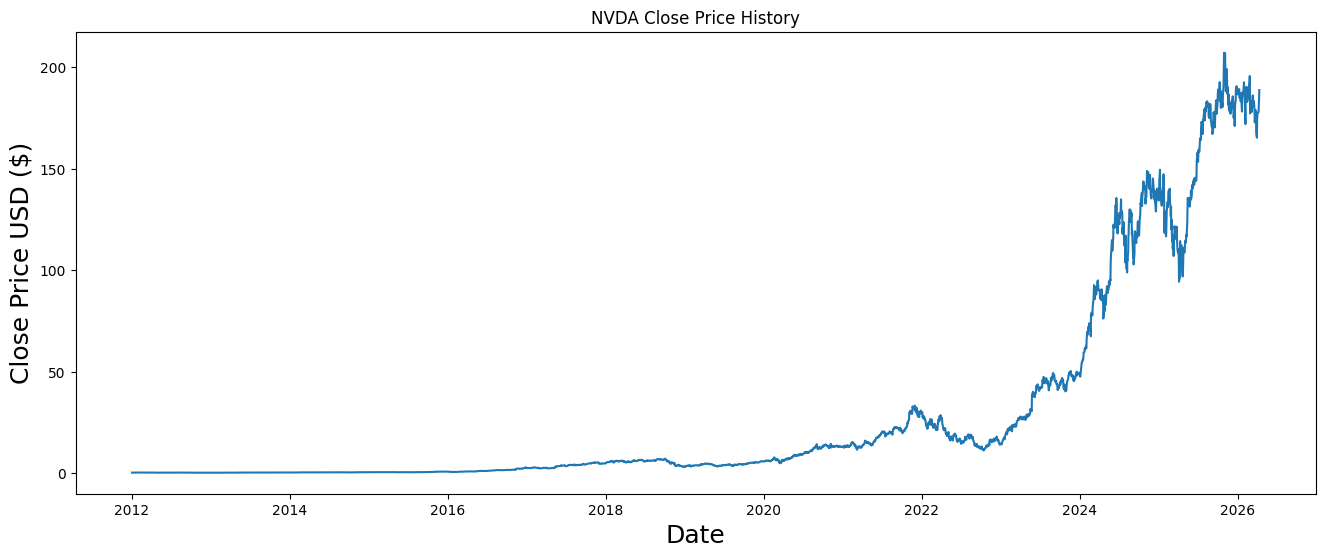

In [ ]:
plt.figure(figsize=(16,6))
plt.title('NVDA Close Price History')
plt.plot(nvda['Close'])
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)
plt.show()

In [ ]:

data = nvda.filter(['Close'])
dataset = data.values
training_data_len = int(np.ceil( len(dataset) * .95 ))

training_data_len

3409

In [ ]:
dataset_nvda = nvda[['Close']]
scaler = MinMaxScaler(feature_range=(0, 1))

scaled_data = scaler.fit_transform(dataset_nvda)
scaled_data

array([[2.94869901e-04],
       [3.12606595e-04],
       [3.69141891e-04],
       ...,
       [8.79388182e-01],
       [8.88239184e-01],
       [9.11067982e-01]])

In [ ]:

train_data = scaled_data[0:int(training_data_len), :]
x_train = []
y_train = []

for i in range(60, len(train_data)):
    x_train.append(train_data[i-60:i, 0])
    y_train.append(train_data[i, 0])
    if i<= 61:
        print(x_train)
        print(y_train)
        print()

x_train, y_train = np.array(x_train), np.array(y_train)

x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))


[array([0.00029487, 0.00031261, 0.00036914, 0.0003503 , 0.0003503 ,
       0.00034365, 0.0003115 , 0.00030152, 0.00026051, 0.00023723,
       0.00028822, 0.00032923, 0.00031482, 0.00035806, 0.00039464,
       0.00038466, 0.00036914, 0.00039131, 0.00037912, 0.00037579,
       0.00039353, 0.00045561, 0.00049219, 0.00047889, 0.00048332,
       0.00054651, 0.0005454 , 0.00050106, 0.00052877, 0.00053875,
       0.00053099, 0.00056203, 0.00049551, 0.00050438, 0.00049219,
       0.00050217, 0.00048886, 0.00045339, 0.00043787, 0.00041792,
       0.000429  , 0.00044341, 0.00038577, 0.00037025, 0.00038023,
       0.00038577, 0.00038134, 0.00035584, 0.00037801, 0.00033145,
       0.00035473, 0.00035695, 0.00036138, 0.00033478, 0.00034143,
       0.00033921, 0.00035141, 0.00037025, 0.00038134, 0.00041903])]
[np.float64(0.00042678564101155856)]

[array([0.00029487, 0.00031261, 0.00036914, 0.0003503 , 0.0003503 ,
       0.00034365, 0.0003115 , 0.00030152, 0.00026051, 0.00023723,
       0.00028822, 0

In [ ]:

model = Sequential()
model.add(LSTM(128, return_sequences=True, input_shape=(x_train.shape[1], 1)))
model.add(LSTM(64, return_sequences=False))
model.add(Dense(25))
model.add(Dense(1))


model.compile(optimizer='adam', loss='mean_squared_error')


model.fit(x_train, y_train, batch_size=5, epochs=5)

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


670/670 ━━━━━━━━━━━━━━━━━━━━ 40s 53ms/step - loss: 6.5048e-04
Epoch 2/5
670/670 ━━━━━━━━━━━━━━━━━━━━ 37s 55ms/step - loss: 2.4537e-04
Epoch 3/5
670/670 ━━━━━━━━━━━━━━━━━━━━ 39s 59ms/step - loss: 2.6500e-04
Epoch 4/5
670/670 ━━━━━━━━━━━━━━━━━━━━ 38s 57ms/step - loss: 2.2441e-04
Epoch 5/5
670/670 ━━━━━━━━━━━━━━━━━━━━ 35s 52ms/step - loss: 1.0964e-04


In [ ]:
test_data = scaled_data[training_data_len - 60:, :]

x_test = []
y_test = dataset[training_data_len:, :]

for i in range(60, len(test_data)):
    x_test.append(test_data[i-60:i, 0])

x_test = np.array(x_test)


x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))


predictions = model.predict(x_test)


predictions = scaler.inverse_transform(predictions)




6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


/tmp/ipykernel_6438/4138169639.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['Predictions'] = predictions[:len(valid)]  # Ensure that predictions align with valid length


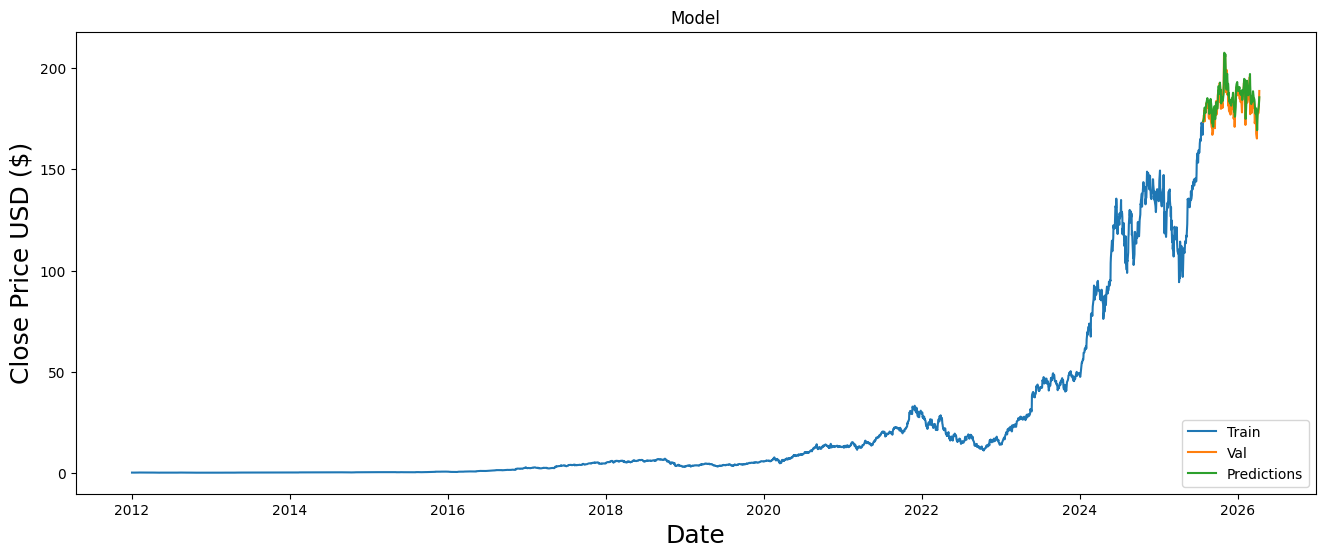

In [ ]:

data = nvda[['Close']]

dataset = data.values

training_data_len = int(np.ceil(len(dataset) * .95))


train = data.iloc[:training_data_len]
valid = data.iloc[training_data_len:]

valid['Predictions'] = predictions[:len(valid)]


plt.figure(figsize=(16,6))
plt.title('Model')
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)


plt.plot(train.index, train['Close'], label='Train')
plt.plot(valid.index, valid['Close'], label='Val')
plt.plot(valid.index, valid['Predictions'], label='Predictions')

plt.legend(loc='lower right')
plt.show()


In [ ]:
valid

Price,Close,Predictions
Ticker,NVDA,
Date,,
2025-07-25,173.471176,173.795197
2025-07-28,176.720627,175.300858
2025-07-29,175.480850,177.774841
2025-07-30,179.240219,178.213287
2025-07-31,177.840439,180.274765
...,...,...
2026-04-06,177.639999,180.111969
2026-04-07,178.100006,181.091690


In [ ]:
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(np.mean((predictions - y_test) ** 2))
rmse

print(f"Root Mean Squared Error (RMSE):{rmse}")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")

Root Mean Squared Error (RMSE):4.832879406094067
Mean Absolute Error (MAE): 3.6970017928650925
Mean Squared Error (MSE): 23.356723353848142
